# 統計モデル選択の妥当性の評価

書籍では異常検知の性能評価手法を⼤きく、「**1.ラベルの予測精度**」、「**2.統計モデル選択の妥当性**」という二つのアプローチに分けて解説しました。

両評価指標の特徴は、以下のようにまとめられます。

||1.ラベルの予測精度|2.統計モデル選択の妥当性|
|---|---|---|
|適用できる異常検知アルゴリズム|教師あり学習、教師なし学習・統計モデリング（異常データが取得可能な場合）|教師なし学習・統計モデリング|
|評価指標の測定内容|ラベルの予測誤差|モデルのデータへの適合度|
|異常検知における評価目的|異常と正常を正しく見分けられるか|モデルがデータをどれだけうまく説明しているか|
|評価に必要なデータ|正常データ＋異常データ|正常データ|
|メリット|ビジネス上のメリットを直接評価できる|異常データなしで計算可能|
|デメリット|異常データがないと計算できない|ビジネス上のメリットに対する直接性が低い|
|代表的な評価指標|精度、適合率、再現率、F値、AU-ROC|対数尤度、AIC、BIC、WAIC|

このnotebookでは、「**2.統計モデル選択の妥当性**」による性能評価の実装方法を解説します。この評価方法は**異常データなしで計算可能**というメリットを持つ代わりに、**ビジネス上のメリットに対する直接性が低い**というデメリットを持ちます。そのため、複数のモデルの中からデータに適合したモデルを選択するモデル選択には活用できますが、モデルの導入効果の評価には向きません。

上記のような特性から、**異常データの取得が困難なケースにおけるモデル選択に役立つ指標**と言えるでしょう。

具体的に求める指標は、統計モデルのパラメータ推定に最尤推定を用いるか、ベイズ推定を用いるかで変わります。

### 最尤推定を用いる場合の評価指標

最尤推定を用いる場合、次の性能指標のPythonによる計算方法を解説します。

- 対数尤度（Accuracy）
- AIC（Precision）
- BIC（Recall）

性能評価の実装法は、モデルのライブラリやデータセットの特性により変わるため、ここでは以下の3パターンそれぞれについて評価方法を解説します。

1. 正規分布による教師なし学習モデル（NumPyのスクラッチ実装モデル）を用いる場合
2. 1変数非正規分布による教師なし学習モデル（Scipyの確率分布クラス）を用いる場合
3. 統計モデリング（statsmodels）を用いる場合

AIC、BICは学習データから未知データに対する汎化性能を推測できることを強みとして持つため、基本的には学習データのみを用いて評価を行います。ただし参考として「1. 教師なし学習モデルを用いる場合」に関しては、テストデータから対数尤度を求める例を。

また、最後にAICやBICが対数尤度と比べて過学習の影響を排除し、未知データに対する汎化性能を評価できることをシミュレーションで確認してみます。

### ベイズ推定を用いる場合の評価指標

ベイズ統計モデリングを用いる場合、次の性能指標のPythonによる計算方法を解説します。

- WAIC（widely applicable information criterion）
- LOO（leave one out）

※LOOは、厳密には指標の名称ではなくデータ分割法を表し、LOOで分割したデータから求めた対数尤度を指します。

PyMCをモデリングに用いれば、専用メソッドで上記の指標を簡単に計算できるため、ここでは以下の1パターンのみを紹介します。

4. ベイズ統計モデリング（PyMC）を用いる場合

こちらも最尤推定のケースと同様、学習データのみを用いて評価を行います。

## 1. 正規分布による教師なし学習モデル（NumPyのスクラッチ実装モデル）を用いる場合

この例では、4章から6章で解説した、正規分布による教師なし学習モデルを用いるケースを想定します。モデルをNumPyでスクラッチ実装しているため、実装にやや手間はかかりますが、評価の詳細な流れを追いやすい例と言えます。

ここでは、2章で作成したサンプルデータと、6章で解説した2変数のホテリング理論（正規分布）のモデルを用います。
まず以下に示すように、[ch6_3_Multivariate_Hotelling.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch6_3_Multivariate_Hotelling.ipynb)で使用した学習データと、学習したモデルのパラメータを読み込みます。

In [10]:
# コード9.15 2変数ホテリング理論（正規分布）モデルの対数尤度の計算
import pandas as pd
import numpy as np

# モデルのパラメータ（6章で学習済み）
MU = [350.23771153, 400.21552883] # 標本平均ベクトルμ
SIGMA = [[26.04088919, 14.52874949],
[14.52874949, 24.58401158]] # 標本分散共分散行列Σ

# CSVからPandas DataFrameに学習用データ読み込み
df_train = pd.read_csv("./datasets/ch2_dataset_train.csv")
# "temp2","temp1"変数に欠測が含まれるデータを削除
df_train = df_train.dropna(subset=["temp2", "temp1"])
X_train = df_train[["temp2", "temp1"]].to_numpy()


### 対数尤度

今回の多変数の正規分布モデル（ホテリング理論の統計モデル）では、対数尤度は書籍の式 (6.44)に基づき、以下のように計算できます。

In [11]:
# 対数尤度の計算
def compute_log_likelihood(X, mu, sigma):
    """対数尤度を計算する関数"""
    X_dev = (X-np.array(mu)).T # 推論データと平均ベクトルとの差（x-μ）
    Sigma_inv = np.linalg.inv(np.array(sigma)) # 標本分散共分散行列の逆行列
    Dev_Sigma = X_dev.T @ Sigma_inv # (x-μ)^T * Σ^-1
    anomaly_scores = np.sum(np.multiply(Dev_Sigma, X_dev.T), axis=1)
    first_term = np.log(2*np.pi) * len(mu)/2 # M/2log(2π)
    second_term = 0.5 * np.log(np.linalg.det(sigma)) # 1/2 log|Σ|
    n = len(X) # N
    log_likelihood = -n*(first_term+second_term) - 0.5*np.sum(anomaly_scores)

    return log_likelihood

log_likelihood = compute_log_likelihood(X_train, MU, SIGMA)
print("対数尤度:", log_likelihood)

対数尤度: -5634.619326385871


**対数尤度は値が大きいほど性能が良い**、すなわちモデルがデータへよくフィットしていることを表します。

#### ※テストデータに対して対数尤度を求める方法

ここでは参考として、テストデータに対して対数尤度を求める方法も示します。

In [12]:
# テストデータに対して対数尤度を計算
# CSVからPandas DataFrameにテストデータ読み込み
df_test = pd.read_csv("./datasets/ch2_dataset_inference.csv")
# "temp2","temp1"変数に欠測が含まれるデータを削除
df_test = df_test.dropna(subset=["temp2", "temp1"])
X_val = df_test[["temp2", "temp1"]].to_numpy()

# テストデータに対する対数尤度の計算（mu,sigmaは学習済みパラメータを使用）
log_likelihood_val = compute_log_likelihood(X_val, MU, SIGMA)
print("テストデータに対する対数尤度:", log_likelihood_val)

テストデータに対する対数尤度: -2785.4366166737072


なお、対数尤度やAIC、BICのような指標は**入力データが異なる場合、その値を比較することはできない**ため、今回テストデータから求めた対数尤度と、先ほど学習データから求めた対数尤度の大小は意味を持ちません。

### AIC

AICは、上で求めた対数尤度を$\log L$、モデルのパラメータ数を$k$としたとき、以下の式で計算できます。

$\mathrm{AIC}=-2(\log L - k)$

この式に基づき、多変数正規分布モデル（ホテリング理論）では以下のようにPythonでAICを求めます

In [13]:
# コード9.17 2変数ホテリング理論（正規分布）モデルのAICの計算
# モデルのパラメータ数の計算
p = X_train.shape[1] # 平均ベクトルμの要素数=2
k = p + p * (p + 1) / 2 # 共分散行列Σのユニーク要素数を足す
# AICの計算
aic = 2 * k - 2 * log_likelihood
print("AIC:", aic)

AIC: 11279.238652771743


**AICは値が小さいほど性能が良い**、すなわちモデルの未知データへの適合度が高いことを表します。

### BIC

BICは、上で求めた対数尤度を$\log L$、モデルのパラメータ数を$k$、学習データ数を$N$としたとき、以下の式で計算できます。

$\mathrm{BIC}=-2(\log L - k\log N)$

この式に基づき、多変数正規分布モデル（ホテリング理論）では以下のようにPythonでBICを求めます

In [14]:
# コード9.17 2変数ホテリング理論（正規分布）モデルのBICの計算
n = len(X_train) # データ数
# BICの計算
bic = np.log(n) * k - 2 * log_likelihood
print("BIC:", bic)

BIC: 11303.42531684517


**BICは値が小さいほど性能が良い**、すなわちモデルの未知データへの適合度が高いことを表します。

## 2. 1変数非正規分布による教師なし学習モデル（Scipyの確率分布クラス）を用いる場合

この例では、4.6節で解説した、1次元非正規分布による教師なし学習モデルを用いるケースを想定します。この方法はScipyの確率分布クラスを用いてモデルを表現しているので、対数尤度を簡単に求められます。

ここでは4.6節と同様に、ガンマ分布から生成したデータと、Scipyの確率分布クラスで表現されたガンマ分布モデルを用います。
まず以下のように、[ch4_6_Non-Normal_Anomaly_Detection.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch4_6_Non-Normal_Anomaly_Detection.ipynb)と同様の方法でガンマ分布から学習データを生成し、ガンマ分布モデルのパラメータを最尤推定します。

In [15]:
# 学習データの生成とガンマ分布モデルのパラメータ推定
from scipy import stats

# 学習用サンプルをガンマ分布から1000個生成
x_train = stats.gamma.rvs(a=3, scale=2, size=1000, random_state=42)
# 正常のモデルを学習
# ガンマ分布を最尤推定（オフセットlocは固定する）
params = stats.gamma.fit(x_train, floc=0)
k = params[0] # 形状母数パラメータk
theta = params[2] # 尺度母数パラメータθ

### 対数尤度

以下のように、`stats.gamma.logpdf`関数で個々のデータの対数尤度を求めたのち、総和をとることでデータ全体の対数尤度を求められます。

In [16]:
# コード9.16 ガンマ分布モデルの対数尤度の計算
# 個々のデータの対数尤度を計算
x_train_logpdf = stats.gamma.logpdf(x_train, a=k, scale=theta, loc=0)
# データ全体の対数尤度を計算
log_likelihood = np.sum(x_train_logpdf)
print("対数尤度:", log_likelihood)

対数尤度: -2545.419735472305


### AIC

式に従い以下のようにAICを計算します

In [17]:
# コード9.18 ガンマ分布モデルのAICの計算
k = 2 # ガンマ分布のパラメータ数（形状母数kと尺度母数θ）
# AICの計算
aic = 2 * k - 2 * log_likelihood
print("AIC:", aic)

AIC: 5094.83947094461


### BIC

式に従い以下のようにBICを計算します

In [18]:
# コード9.18 ガンマ分布モデルのBICの計算
bic = np.log(len(x_train)) * k - 2 * log_likelihood
print("BIC:", bic)

BIC: 5104.654981502575


## 3. 統計モデリング（statsmodels）を用いる場合

この例では、7章で解説した統計モデリング（statsmodelsによる最尤推定ベースの回帰的手法）を用いるケースを想定します。このケースではstatsmodelsの専用メソッドを用いることで、各種指標を簡単に求められます。

ここでは、7章で作成したサンプルデータと、7章で解説した線形回帰モデルを用います。以下に示すように、[ch7_4_Multivariate_Linear_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch7_4_Multivariate_Linear_Regression.ipynb)の手順で学習したモデルを用います。

In [19]:
# 性能評価指標算出に使用するデータとモデル
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm

TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）

# 学習データ読み込み
df_train = pd.read_csv('./datasets/usedcar_dataset_train.csv')
df_normal = df_train[df_train['label'] == 'normal']  # 正常データのみを抽出
# カテゴリ変数'model_name'の数値化（one-hot encoding）
enc = OneHotEncoder(drop='first')
model_name_cat = enc.fit_transform(df_normal[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_normal.drop('model_name', axis=1), df_model_name], axis=1)
# 学習データの説明変数と応答変数（'price'）を別々に保持（応答変数のみndarray化）
X_train = df_encoded[['year', 'odometer']+model_cat_names]
y_train = df_encoded['price'].to_numpy()
# モデルの学習
X_train_intercept = sm.add_constant(X_train) # 切片を追加
mod = sm.OLS(y_train, X_train_intercept) # 線形回帰モデル（OLS）を作成
res = mod.fit() # モデルの学習を実行

statsmodelsの統計モデルでは、学習結果を表すインスタンス（上記コード中の`res`）の`summary`メソッドで学習済のモデル情報を一括表示できます。この中に対数尤度（Log-Likelihood）やAIC、BICも含まれています。

In [20]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     1784.
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        02:32:33   Log-Likelihood:                -4623.1
No. Observations:                1000   AIC:                             9256.
Df Residuals:                     995   BIC:                             9281.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              348.5625      2.272    153.395      0.000     344.103     353.022
year               -10.6684      0.515    -20.699      0.000     -11.680      -9.657
odometer            -3.8008      0.649     -5.856      0.000      -5.074      -2.527
model_name_sedan    48.5841      2.092     23.220      0.000      44.478      52.690
model_name_suv     145.5779      3.094     47.048      0.000     139.506     151.650
==============================================================================
Omnibus:                        4.536   Durbin-Watson:                   2.029
Prob(Omnibus):                  0.104   Jarque-Bera (JB):                4.576
Skew:                           0.148   Prob(JB):                        0.101
Kurtosis:                       2.853   Cond. No.                         38.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

また、対数尤度、AIC、BICの値を取得して利用したい場合、学習結果を表すインスタンス（上記コード中の`res`）のメンバ変数`lif`、`aic`、`bic`からそれぞれ取得できます。

In [21]:
# 対数尤度、AIC、BICの取得
log_likelihood = res.llf
aic = res.aic
bic = res.bic
print("対数尤度:", log_likelihood)
print("AIC:", aic)
print("BIC:", bic)

対数尤度: -4623.110440487552
AIC: 9256.220880975105
BIC: 9280.759657370016


#### ※テストデータに対して対数尤度を求める方法

ここでは参考として、テストデータに対して対数尤度を求める方法も示します。
statsmodelsには新規データに対して対数尤度を直接計算する関数はないため、書籍の式 (7.26)の対数尤度の式

$\log L(\boldsymbol{y} \mid \boldsymbol{X}, \boldsymbol{w}, w_0, \sigma^2) =\frac{N}{2}\log(2 \pi) - \frac{N}{2}\log \sigma^2 - \frac{1}{2\sigma^2}\sum_{i=1}^N (y^{(i)}-(\boldsymbol{w}^T\boldsymbol{x}^{(i)}+w_0))^2$

に基づき計算する関数を以下のように実装します。

In [22]:
# テストデータに対して対数尤度を計算
def compute_log_likelihood(X, y, res):
    """対数尤度を計算する関数"""
    w = res.params[1:].to_numpy() # パラメータw
    w_0 = res.params[0] # パラメータw_0
    sigma2 = res.scale*res.df_resid / mod.nobs # パラメータσ^2（scaleは不偏推定値）
    sse = (y - w@X.T - w_0)**2 # 残差平方和SSE
    n = len(y) # データ数N
    # 対数尤度の計算（書籍の式7.26に従う）
    log_likelihood = -n/2 * np.log(2 * np.pi * sigma2) - np.sum(sse) / (2 * sigma2)
    return log_likelihood

# CSVからPandas DataFrameにテストデータ読み込み
df_test = pd.read_csv('./datasets/usedcar_dataset_inference.csv')
true_labels = df_test['label'].to_numpy()  # 正解ラベルを保持
# カテゴリ変数'model_name'の数値化（one-hot encoding）
model_name_cat = enc.transform(df_test[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_test.drop('model_name', axis=1), df_model_name], axis=1)
# 推論データの説明変数（'year'）と応答変数（'price'）をNumpyのndarray化
X_test = df_encoded[['year', 'odometer']+model_cat_names].to_numpy()
y_test = df_encoded['price'].to_numpy()
# テストデータに対する対数尤度の計算（学習済みパラメータを使用）
log_likelihood_test = compute_log_likelihood(X_test, y_test, res)
print("テストデータに対する対数尤度:", log_likelihood_test)

テストデータに対する対数尤度: -2909.6640307673442


/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_13677/821484858.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  w_0 = res.params[0] # パラメータw_0


## 4. ベイズ統計モデリング（PyMC）を用いる場合

この例では、8章で解説したベイズ統計モデリング（PyMCによるベイズ推定ベースの回帰的手法）を用いるケースを想定します。このケースではPyMCの専用メソッドを用いることで、各種指標を簡単に求められます。

ここでは、7章で作成したサンプルデータと、8章で解説したベイズ線形回帰モデルを用います。以下に示すように、[ch8_4_Bayesian_Linear_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch8_4_Bayesian_Linear_Regression.ipynb)の手順で学習したモデルを用います。WAIC等の指標を求めるためには、MCMCサンプリングを実施する`pm.sample`関数の`idata_kwargs`引数に、対数尤度計算の有効化を表す辞書`{"log_likelihood": True}`を渡す必要があります。

In [23]:
# 性能評価指標算出に使用するデータとモデル
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import pymc as pm
import arviz as az
import xarray as xr
from scipy import stats

TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）

# 学習データ読み込み
df_train = pd.read_csv('./datasets/usedcar_dataset_train.csv')
df_normal = df_train[df_train['label'] == 'normal']  # 正常データのみを抽出
# カテゴリ変数'model_name'の数値化（one-hot encoding）
enc = OneHotEncoder(drop='first')
model_name_cat = enc.fit_transform(df_normal[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_normal.drop('model_name', axis=1), df_model_name], axis=1)
# 学習データの説明変数と応答変数（'price'）を別々に保持してndarray化
X_train = df_encoded[['year', 'odometer']+model_cat_names].to_numpy()
y_train = df_encoded['price'].to_numpy()
# モデルの学習
seed=42 # 乱数シードを指定（結果の再現性を担保）
multi_regression_model = pm.Model()
with multi_regression_model:
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0 = pm.Normal("w_0", mu=0, sigma=100)
    w = pm.Normal("w", mu=0, sigma=100, shape=4)
    sigma = pm.HalfNormal("sigma", sigma=100)
    # 線形予測子
    mu = w_0 + w[0]*X_train[:, 0] + w[1]*X_train[:, 1] \
        + w[2]*X_train[:, 2] + w[3]*X_train[:, 3]
    # 確率分布
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=y_train)
    # MCMCの実行（学習）
    with multi_regression_model:
        trace = pm.sample(random_seed=seed,
                          idata_kwargs={"log_likelihood": True})
# 各パラメータのMCMCサンプルの概要を表示
print(az.summary(trace, round_to=2))
# MCMCサンプルを保持
posterior_mcmc = trace.posterior

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0, w, sigma]


Output()

/Users/knakamura/miniforge3/envs/anomaly_detection/lib/python3.13/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


         mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
w_0    348.56  2.28  344.25   352.88       0.06     0.04   1537.97   2278.80   
w[0]   -10.68  0.51  -11.70    -9.76       0.01     0.01   1327.48   1890.25   
w[1]    -3.77  0.65   -4.96    -2.53       0.02     0.01   1321.31   2066.43   
w[2]    48.52  2.08   44.63    52.44       0.05     0.03   1787.90   2155.56   
w[3]   145.38  3.14  139.86   151.46       0.09     0.05   1325.09   2233.66   
sigma   24.74  0.56   23.65    25.77       0.01     0.01   2890.87   2342.65   

       r_hat  
w_0      1.0  
w[0]     1.0  
w[1]     1.0  
w[2]     1.0  
w[3]     1.0  
sigma    1.0  


### WAIC

**WAIC**（widely applicable information criterionまたはWatanabe–Akaike information criterion）は、ベイズ推定における汎化性能評価のための代表的な指標であり、以下の式で表されます（説明変数x と応答変数$y$が区別され、かつMCMCにより事後分布に従うサンプルが得られているケースを想定）。

$\mathrm{WAIC} = -\frac{1}{2}\bigg(\sum_{i=1}^N \log \Big( \frac{1}{L} \sum_{t=1}^L p(y^{(i)} \mid \boldsymbol{x}^{(i)},\boldsymbol{\theta}^{(t)}) \Big) + \sum_{i=1}^N V_{t=1}^L \big[\log p(y^{(i)} \mid \boldsymbol{x}^{(i)},\boldsymbol{\theta}^{(t)})\big]\bigg)$

PyMCにおいては、`idata_kwargs`引数に`{"log_likelihood": True}`を渡してMCMCサンプリング実行後、以下のように得られたサンプルを`arviz.waic`関数に渡すことで、WAICを計算できます。

In [24]:
# コード9.21 WAICの計算

import arviz as az

waic = az.waic(trace)
waic

Computed from 4000 posterior samples and 1000 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -4629.09    21.53
p_waic        5.94        -

### LOO

ベイズ統計モデリングにおけるLOO（leave one out：1個抜き交差検証）は、[ch9_3_Cross_Varidation_And_Parameter_Tuning.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch9_3_Cross_Varidation_And_Parameter_Tuning.ipynb)で解説するデータ分割法の一つであるLOOで求めた対数尤度を指します。

多くの場合、計算負荷が非常に高いLOOによる実際のデータ分割は行わず、近似的に計算する方法が用いられます。PyMCにおいては、ArVizの`az.loo`関数で、PSIS（Pareto-smoothed importance sampling：パレート平滑化重要度サンプリング）と呼ばれる方法で計算された近似値が得られます。

In [25]:
# コード9.22 LOOの計算

loo = az.loo(trace)
loo

Computed from 4000 posterior samples and 1000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -4629.10    21.53
p_loo        5.95        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1000  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

## モデル選択のTips

### 評価指標によるモデル選択ができる条件

このnotebookで解説した「2.統計モデル選択の妥当性」に基づく評価指標は、その値の大小を比較できるかどうかに条件があります。ここではその条件についてTipsを紹介します

まず、この評価指標で異なるモデルを比較・選択するためには、基本的には以下の条件が必須となります

1. 同じデータで推定されていること
2. 同じ変数（応答変数）に対して尤度が定義されていること

また、AICやBICを用いる場合は更に注意が必要なため、こちらについても後述します。

#### 1. 同じデータで推定されていること

AICやBIC、WAICのような指標は、データが異なると値の大小を比較することができません。例えば独立同分布（後述）における対数尤度の計算式である、本文中の式 (4.19)

$L(\boldsymbol{\theta})=\prod_{i=1}^N p(\boldsymbol{x}^{(i)} \mid \boldsymbol{\theta})$

を見ると、サンプルサイズ$N$が増えると対数尤度が増えていくため、サンプルサイズが異なるデータセットの対数尤度の大小を比較できないことからも明らかです。

データが異なれば評価指標の大小比較ができないのは当たり前のように見えますが、他の指標であればそうではない（データが異なっても指標の大小比較がある程度可能）事例もあります。例えば相関係数であれば、0.9ならば高い相関、0.1ならば低い相関というように、データが異なっていてもある程度同様の基準で比較することができます。

[ch9_3_Classification_Metrics.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch9_3_Classification_Metrics.ipynb)で紹介したラベルの予測精度に基づく指標も、F値が0.95であれば良い分類性能とみなせるというように、データが異なっていてもある程度同様の基準で比較することができます。

#### 2. 同じ変数（応答変数）に対して尤度が定義されていること

全てのモデルにおいて、確率密度が同じ変数（入出力のない手法では変数$\boldsymbol{x}$、入出力のある回帰的統計モデリングでは応答変数$y$）に対して定義されていなければ

「同じ変数」というのは、文字通りただ同じ変数を使用しているだけでなく、離散・連続型の一致や、非線形な変換が行われていないかにも注意が必要です。

例えばある生産ラインでの1日あたり不良数を統計モデリングで予測する場合、あるモデルでは不良数を線形回帰モデル（正規分布のGLM）で予測し、あるモデルでは不良数を計数データとみなしてポアソン回帰や二項ロジスティック回帰で予測した場合。前者では連続的な確率密度から対数尤度を求めており、後者では離散的な確率質量から対数尤度を求めているため、基準が全く異なるこれらの指標を単純比較することはできないからです。
またポアソン回帰（1日でラインが動いていた時間を観測区間$t$とする）と二項ロジスティック回帰（1日の生産数を試行数$N$とする）に関しても、同じ計数データであっても前者は台の上限が無限大なのに対し、後者は上限$N$が決まっているため、厳密には単純比較できません（ただし二項ロジスティック回帰の上限$N$を上回る範囲での確率質量はポアソン回帰でも非常に小さいため、ある程度の比較はできると考えられます）。

また、あるモデルでは応答変数$y$から尤度を求めているのに、他のモデルでは変数変換を行なっていて応答変数$y$の対数$\log y$に対して尤度を求めている場合、非線形な変換により尤度の基準が変化するため、指標の大小を比較することはできません。複雑な現象のモデル化では知らず知らずのうちに変数変換を行なっていることもあるので、注意が必要です。

### AICやBICを用いている場合の注意点

AICやBICは、学習データから汎化性能を求められるように様々な工夫が凝らされた指標ですが、この工夫が正しく機能するためには条件が必要です。

この条件には多くの議論がありますが、よく挙げられるものには以下のようなものがあります。

3. 最尤推定されたモデルであること（例：ベイズ推定やMAPEの最大化等で学習したモデルには不適）
4. 尤度やパラメータ数の定義が同じであること（GLMMのような階層モデルではこの判断が難しいので、AICやBICはあまり用いられない）
5. 時系列データの場合、使用するデータの系列や差分の次数を揃える

これらの条件を確実にクリアするため、AICやBICは「同種の確率分布を用いたGLMにおいて、変数を選択する」用途でよく用いられます。

なお、ソースが不十分なTipsも多いので、もしより良いソースをご存知の方がいれば[GitHubのIssues](https://github.com/ghmagazine/python_anomaly_detection_book/issues)か[Twitter](https://x.com/c60evaporator)のDMでご連絡頂けますと幸いです。

#### 3. 最尤推定されたモデルであること

書籍中でも解説したように、AIC（やBIC）の理論には、学習データの対数尤度を最大化するようパラメータ推定したモデルにおいて、学習データの対数尤度（最大対数尤度）と未知データの対数尤度との差分を推定するという前提があります。よって各モデルが対数尤度を最大化するようにパラメータ推定、すなわち最尤推定されていなければ、この前提条件が崩れてしまいます。

よって[こちら](https://robjhyndman.com/hyndsight/aic/)にも記載されているように、MAPEを最大化するよう最適化した線形回帰モデル（最尤推定であればMSEを最大化する必要がある）や、ベイズ推定したモデルについては、AICやBICを適用することができません。

#### 4. 尤度やパラメータ数の定義が同じであること

各モデルで尤度やパラメータ数の定義が揃っていないと、ここから求めたAICやBICの大小を比較することができません。
これらの問題が顕在化するのが、階層モデルです。

単純な確率分布の当てはめやGLMであれば、尤度は推定されたパラメータ（と説明変数）から一意に決まる確率分布において、観測データが得られる確率から計算できます。この対数をとったものが、AICやBICの計算で用いるべき対数尤度です。
一方でランダム効果を含む階層モデルでは、確率的に生成された下位のパラメータ（ランダム効果項）が与えられた条件のもとで、上位の確率分布において観測データが得られる確率から計算される、条件付き尤度として定義されます。この条件付き尤度を前述のGLMにおける尤度の定義に揃えるためには、全てのランダム効果項のとる値のパターンを網羅するよう、ランダム効果項の確率密度をかけて積分し、周辺化する必要があります。この積分計算は書籍の式 (8.55)でも言及したように複雑で困難であり、多くの実装ではランダム効果項の点推定値を条件付き尤度に代入してAICを求めているため、本来求めるべき周辺化した尤度とは異なる定義となっています。

また同様にパラメータ数$k$に関しても、階層モデルではランダム効果に関連したパラメータ（ランダム効果項やハイパーパラメータ）の数をどのように扱うかの定義が難しく、異なるモデル間での厳密な比較が困難となります。

これに対して、テストデータから求めた対数尤度や、WAIC、LOOのようなベイズ推定ベースの指標は、上記のような問題は顕在化しづらいと言えます。途中のモデル構造を明示的には考慮せず、予測分布と実際のデータの分布との整合性を見ており、またパラメータ数を計算式に含まないからです。階層モデルでベイズ推定（MCMC）が広く用いられる背景には、パラメータ推定が容易であることに加え、WAICやLOOを自然に計算でき、モデル比較が適切に行えるという利点があります。

#### 5. 時系列データの場合、使用するデータの系列や差分の次数を揃える

書籍では随所で「すべてのデータが独立の場合」という表現を使っていましたが（例：式 (4.19)の解説）、本書で紹介した手法の多くは**独立同分布**（independent and identically distributed略してIIDやi.i.d.とも呼ばれる）という仮定を置いています。この仮定は、各データが独立（前のデータに影響を受けない）であり、かつ同一の確率分布（確率分布の種類もパラメータも等しい）に従うことを指します。
GLMのような回帰的な統計モデルでも、各データは独立であることを前提としています。また応答変数の確率分布は説明変数に依存して変化するため、厳密には同分布ではありませんが、説明変数から一意に確率分布が決まるため、評価上は独立同分布に近い特性を持ちます。

これに対して時系列モデルでは、データが従う確率分布は他のデータ（前のデータ）に依存した条件付き確率分布となります。このような時系列モデルでは、各データの尤度は他のデータに依存した条件付き尤度となります。よって階層モデルと同様に、尤度の計算条件には注意が必要です。

ARやARIMA、ETSのような主要な時系列モデル（状態空間モデルに位置付けられる手法）では一般的に、特定の共通条件で求められた条件付き尤度を用いて、AICやBICが計算されます。よってAICやBICを用いること自体に問題はなく、モデル選択に広く用いられているのですが、この「特定の共通条件」を揃えないと、異なるモデルの比較ができなくなります。

具体的には、以下の条件を共通化することが重要です。

- 評価に使用するデータの系列を揃える
- 差分の次数を揃える

それぞれ解説します。

##### 評価に使用するデータの系列を揃える

例えばシンプルな時系列モデルであるARでは、時刻$t$時点のデータ$y_t$の条件付き確率密度関数$p(y_t \mid y_{t-1}, \cdots, y_{t-p})$は以下の式で表されます。

$p(y_t \mid y_{t-1}, \cdots, y_{t-p}) = \mathcal{N}(c + \sum_{j=1}^p \phi_j y_{t-j},\sigma^2)$

このモデルには、$y_t$が過去何データに依存するかを表す$p$というパラメータが含まれます。このとき、$p=1$の場合と$p=2$の場合の対数尤度を使用できるデータ全てに対して素直に求めた

$\sum_{t=2}^N \log p(y_t \mid y_{t-1}) = \sum_{t=2}^N \log \mathcal{N}(c + \phi_1 y_{t-1},\sigma^2)$

と

$\sum_{t=3}^N \log p(y_t \mid y_{t-1},y_{t-2}) = \sum_{t=3}^N \log \mathcal{N}(c + \phi_1 y_{t-1} + \phi_2 y_{t-2},\sigma^2)$

をAICやBICの計算に用いてしまうと、対数尤度の計算対象データが異なることとなります。そこで$p=1$の対数尤度の計算対象データを$p=2$に揃えて

$\sum_{t=3}^N \log p(y_t \mid y_{t-1}) = \sum_{t=3}^N \log\mathcal{N}(c + \phi_1 y_{t-1},\sigma^2)$

とすることで、データ数を揃えることができます。このように複数のモデルを比較するためには、探索対象のパラメータのうち最も過去のデータに依存する条件に合わせ、対数尤度の計算対象データを共通化する必要があります。

AR以外の状態空間モデル、例えばARMAにおいても、対数尤度の計算対象データを最も過去のデータに依存するモデルに共通化することで、ARとARMAのような異なるモデル同士の比較が可能となります。

##### 差分の次数を揃える

ARIMAモデルに代表されるように、いくつかの時系列モデルでは、データのトレンドを表現するために過去のデータとの$d$次差分、すなわち

$d=1$の場合：$\Delta y_t = y_t - y_{t-1}$

$d=2$の場合：$\Delta^2 y_t = \Delta y_t - \Delta y_{t-1} = y_t - 2y_{t-1} + y_{t-2}$

を、モデリング時に確率分布に従う変数、すなわち尤度の計算対象とする確率変数として用いています。

[こちら](https://robjhyndman.com/hyndsight/aic/)でも指摘されているように、この差分の次数$d$が異なる条件では、基本的にAICの大小を比較することができません。これは、尤度の計算対象のデータが

$d=1$のARIMA：$(\Delta y_1,\cdots,\Delta y_{N-1}) = (y_2 - y_1,\cdots,y_N - y_{N-1})$

$d=2$のARIMA：$(\Delta^2 y_1,\cdots,\Delta^2 y_{N-2}) = (y_3 - 2y_2 + y_1,\cdots,y_N - 2y_{N-1} + y_{N-2})$

というように異なることが理由です。

同様の理由で、ARやARMAは$(y_1,\cdots,y_N)$を尤度の計算対象のデータとするため、基本的には$d\geq 1$のARIMAとAICの大小を比較することはできません。

他にも[こちら](https://robjhyndman.com/hyndsight/aic/)では、ARIMAとETSをAICで単純比較することはできないことが言及されています。

### AICによるモデル選択の経験則

[こちらの論文](http://faculty.washington.edu/skalski/classes/QERM597/papers_xtra/Burnham%20and%20Anderson.pdf)で言及されているように、AICによるモデル選択には、よく用いられる有用な経験則（rules of thumb）が存在します。

この経験則は、**AICと他の要素を複合的に考慮してモデルを選択したい**場合に有用な基準となります。考慮すべき「他の要素」の代表例として、例えば以下が挙げられます。

- ドメイン知識の裏付け
- モデルの単純さ（シンプルなモデルは運用や説明可能性の観点で利点がある）
- [ch9_2_Preprocessing.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch9_2_Preprocessing.ipynb)で解説した変数選択に関する知識

この方法では、候補となるモデルから求めたAICの最小値（最良モデルでのAIC）を$\mathrm{AIC}_{\mathrm{min}}$としたとき、$i$番目の候補モデルのAICである$\mathrm{AIC}_i$との差分$\Delta_{i} = \mathrm{AIC}_i - \mathrm{AIC}_{\mathrm{min}}$に対して、以下の判断基準を用います。

|対象モデルと最小のAICとの差分$\Delta_{i}$|判断|
|---|---|
|$\Delta_{i}\geq 2$|対象モデルはAIC最小のモデルとほぼ同等に良いとみなせ、採用が強く支持される（substantial support）|
|$4 \geq \Delta_{i} \geq 7$|対象モデルはAIC最小のモデルと明確な差があり、採用は弱く支持される（considerably less support）|
|$\Delta_{i} > 10$|対象モデルはAIC最小のモデルと圧倒的な差があり、採用は支持されない（essentially no support）|

慣例的には、例えば$\Delta_{i}\geq 2$であればAICよりも他の要素を優先してモデル選択をし、$\Delta_{i} > 10$であれば他の要素に関わらずそのモデルを棄却する。その中間的な$\Delta_{i}$であれば、AICと他の要素を両方考慮してモデルを選択する、といった具合で使用されます。

### AICとBICの過学習防止効果の確認

AICやBICが対数尤度と比べて過学習の影響を排除し、未知データに対する汎化性能を評価できることを、書籍中でも解説したGMMを題材としたシミュレーションで確認してみます。

書籍中の式（6.53）で示したGMMにおいて、1次元の例

$p(x \mid \boldsymbol{\theta}) = \sum_{k=1}^c \pi_k \mathcal{N}(x \mid \mu_k, \sigma_k^2)$

を考えます。その確率分布は$c$個の1次元正規分布を混合させたものであるため、この正規分布の個数$c$が1増えるごとに、そのパラメータ数は係数$\pi_k$、平均$\mu_k$、分散$\sigma_k^2$の3個増えることになります。
このとき、学習データを模して1次元正規分布から、以下のように100個のデータを生成します

(-3.0, 3.0)

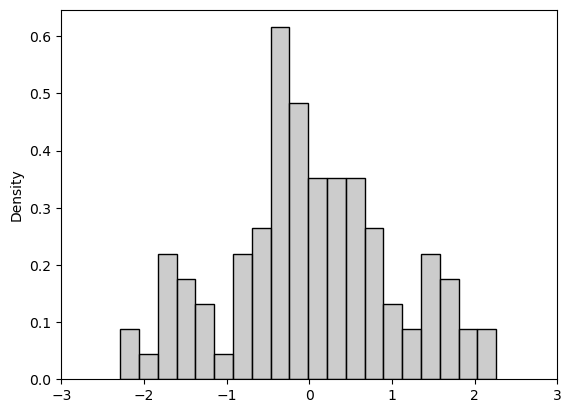

In [26]:
# 1次元正規分布からのサンプル生成とヒストグラム表示
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

seed = 7  # 乱数シード
x = stats.norm.rvs(loc=0, scale=1, size=100, random_state=seed)

sns.histplot(x=x, bins=20, color="#bbbbbb", stat="density")
plt.xlim(-3, 3)

このデータに対し、単一の正規分布モデル（$c = 1$のGMM）と$c = 3$のGMMをそれぞれ最尤推定でパラメータ推定してみます。$c = 1$のモデルはパラメータ数が2（平均、分散）、$c = 3$のモデルはパラメータ数が8です。推定した確率密度関数（黒線）と、それぞれのモデルに対して学習データから求めた対数尤度（Log Likelihood）をプロットします。

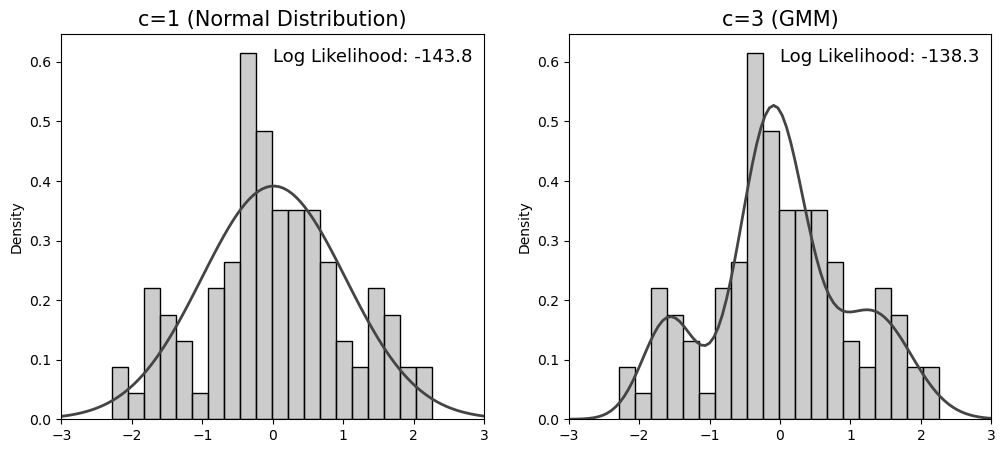

In [27]:
import numpy as np
from sklearn.mixture import GaussianMixture

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# c=1（単一の正規分布）
mean = np.mean(x)  # 平均
std = np.std(x)  # 標準偏差
x_density = np.linspace(-3, 3, 100)  # 描画するX軸用データの生成
pdf_norm = stats.norm.pdf(x_density, loc=mean, scale=std)  # 正規分布の確率密度関数
log_likelihood_norm = np.sum(stats.norm.logpdf(x, loc=mean, scale=std))  # 対数尤度の計算
# ヒストグラムと重ねてプロット
sns.histplot(x=x, bins=20, color="#bbbbbb", stat="density", ax=axes[0])
axes[0].plot(x_density, pdf_norm, color="#444444", linewidth=2)
axes[0].set_title("c=1 (Normal Distribution)", fontsize=15)
axes[0].set_xlim(-3, 3)
axes[0].text(0, 0.6, f"Log Likelihood: {log_likelihood_norm:.1f}", fontsize=13)

# c=3 (GMM)
gmm = GaussianMixture(n_components=3, random_state=42)  # GMMモデルを作成
gmm.fit(x.reshape(-1, 1))  # モデルを学習
pdf_gmm = gmm.score_samples(x_density.reshape(-1, 1))  # GMMの確率密度関数
log_likelihood_gmm = gmm.score(x.reshape(-1, 1)) * len(x)  # 対数尤度の計算
# ヒストグラムと重ねてプロット
sns.histplot(x=x, bins=20, color="#bbbbbb", stat="density", ax=axes[1])
axes[1].plot(x_density, np.exp(pdf_gmm), color="#444444", linewidth=2)
axes[1].set_xlim(-3, 3)
axes[1].set_title("c=3 (GMM)", fontsize=15)
axes[1].text(0, 0.6, f"Log Likelihood: {log_likelihood_gmm:.1f}", fontsize=13)
plt.show()

データの生成元が単一の正規分布なので、本来は$c = 1$が「正しい」モデルです。それにもかかわらず$c = 3$のモデルの方が対数尤度が高く（良く）なっています。これは$c = 3$のモデルは任意の$c = 1$のモデルを再現できる（内包関係を持つ）上に、$c = 1$以上に細かくフィットできるためです。統計モデリングにおいては、このモデル同士の内包関係をネスト（nest）したモデルと呼びます。

ヒストグラムをよく見ると、学習データの分布には生成元の正規分布には存在しない、偶然により生じた⼩さな山（$x=−1.5$および$1.5$付近）が現れています。学習した確率密度の線を見ると、$c = 3$のモデルはこのような⼩さな山にもフィットしているのに対し、$c = 1$のモデルはフィットしていません。$c = 3$のようなパラメータ数の多いモデルは、この山のような偶然生じたデータのばらつきによる特徴にも過剰にフィッティングする、いわゆる**過学習**（overfitting）しやすい傾向があることが、図からも見てとれます。

これに対し、AICとBICを求めて再度プロットしてみます。

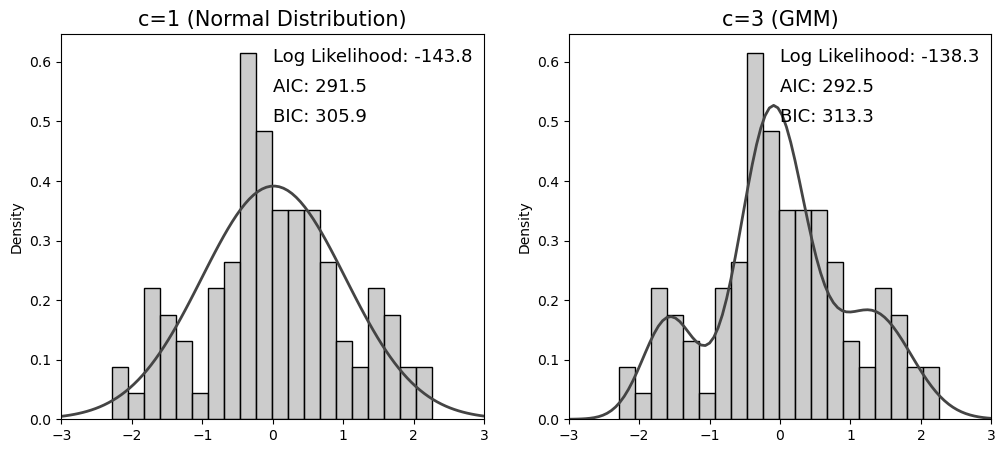

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# c=1（正規分布の最尤推定）
aic_norm = -2 * log_likelihood_norm + 2 * 2  # AICの計算（パラメータ数は2）
bic_norm = -2 * log_likelihood_norm + 2 * 2 * np.log(len(x))  # BICの計算（パラメータ数は2）
# ヒストグラムと重ねてプロット
sns.histplot(x=x, bins=20, color="#bbbbbb", stat="density", ax=axes[0])
axes[0].plot(x_density, pdf_norm, color="#444444", linewidth=2)
axes[0].set_title("c=1 (Normal Distribution)", fontsize=15)
axes[0].set_xlim(-3, 3)
axes[0].text(0, 0.6, f"Log Likelihood: {log_likelihood_norm:.1f}", fontsize=13)
axes[0].text(0, 0.55, f"AIC: {aic_norm:.1f}", fontsize=13)
axes[0].text(0, 0.5, f"BIC: {bic_norm:.1f}", fontsize=13)

# c=3 (GMM)
aic_gmm = -2 * log_likelihood_gmm + 2 * 8  # AICの計算（パラメータ数は8）
bic_gmm = -2 * log_likelihood_gmm + 8 * np.log(len(x))  # BICの計算（パラメータ数は8）
# ヒストグラムと重ねてプロット
sns.histplot(x=x, bins=20, color="#bbbbbb", stat="density", ax=axes[1])
axes[1].plot(x_density, np.exp(pdf_gmm), color="#444444", linewidth=2)
axes[1].set_xlim(-3, 3)
axes[1].set_title("c=3 (GMM)", fontsize=15)
axes[1].text(0, 0.6, f"Log Likelihood: {log_likelihood_gmm:.1f}", fontsize=13)
axes[1].text(0, 0.55, f"AIC: {aic_gmm:.1f}", fontsize=13)
axes[1].text(0, 0.5, f"BIC: {bic_gmm:.1f}", fontsize=13)
plt.show()

対数尤度では$c = 3$のモデルの方が良い結果（高い値）となっていましたが、AICやBICではパラメータ数に比例した罰則項が適用された結果、$c = 1$のモデルの方が良い結果（低い値）となっています。ここで使用したデータは$c = 1$のモデルと同様の1次元正規分布から生成されたものなので、AICやBICを使用した場合に「正しい」モデルが選択されていることがわかります。

このように**AICやBIC**はパラメータ数が増えた際の学習データへの過剰なフィット（過学習）を補正することで、未知データ（真の分布から生成されたデータ）を推定する能力、すなわち**汎化性能をよりよく評価できる**ことがわかります。